# Python and Machine Learning for Plant Pathologists

This tutorial is developed by [Xing Wei](https://www.linkedin.com/in/xingwei19) as part of the APS Plant Health 2025: Python and Machine Learning for Plant Pathologists workshop on August 2, 2025 in Honolulu, Hawaii.

The section on linear regression was inspired by a machine learning course from [Google for Developers](https://developers.google.com/). The section on classification was adapted from the APS's very first [Introduction of Python and Machine Learning in Phytopathology workshop](https://github.com/MohsinRamay/Introduction-of-Python-and-Machine-Learning-in-Phytopathology-)​ , lectured by [Muhammad Mohsin Raza](https://www.linkedin.com/in/muhammad-mohsin-raza/) and [Xing Wei](https://www.linkedin.com/in/xingwei19).



### Outline

In this tutorial, we will practice on two types of supervised machine learning (ML):

1.   Linear regression

*   Exploring Loss
*   Gradient descent

2.   Classification

*   Model training and prediction
*   Accuracy assessment
*   Feature importance

### Setup environment

In [ ]:
# mount Google Drive as a directory within the Colab environment for data access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# set the working directory
%cd /content/drive/MyDrive/APS_Python_Workshop_2025/xw

/content/drive/MyDrive/APS_Python_Workshop_2025/xw


In [ ]:
# check the current work directory
!pwd

/content/drive/MyDrive/APS_Python_Workshop_2025/xw


##**Supervised learning**

It is the types of data that determine which kind of model to build.

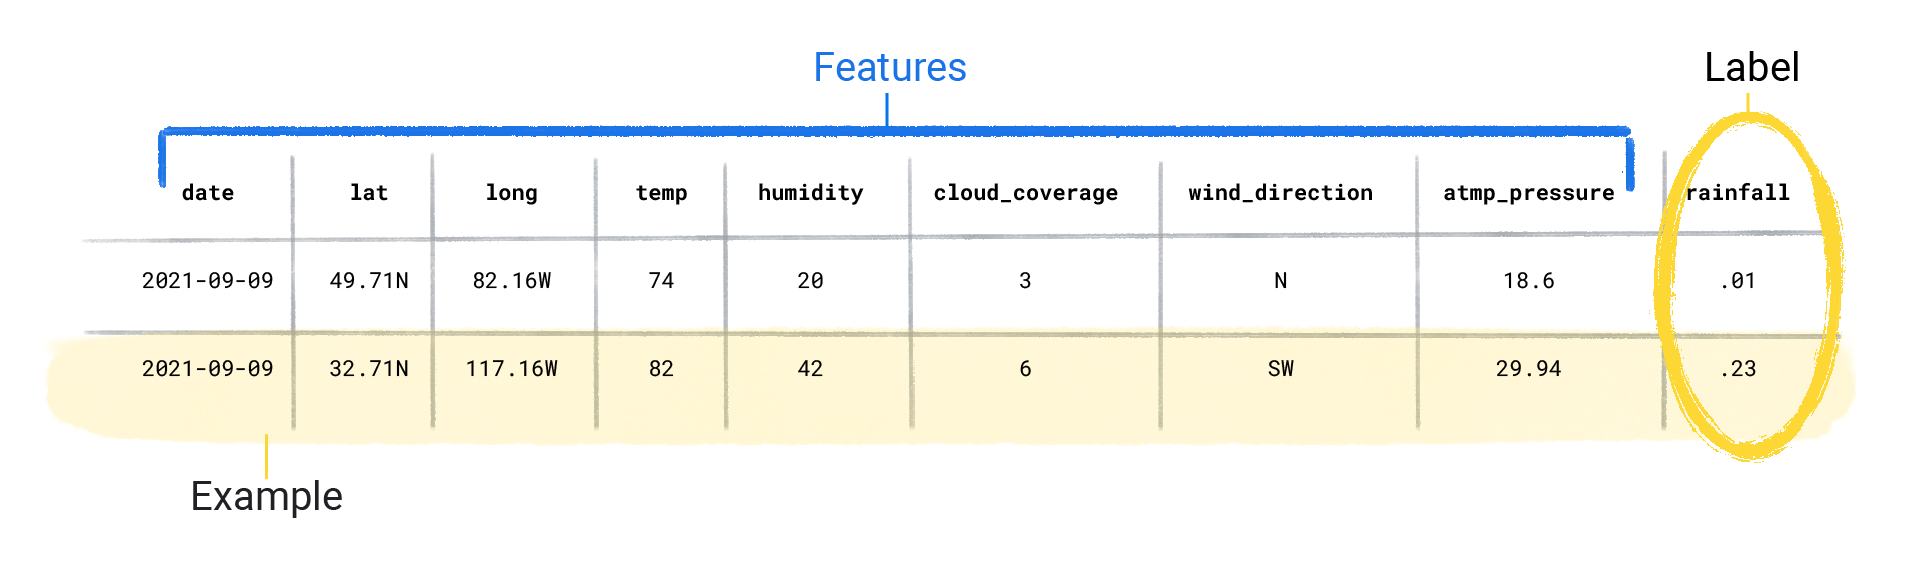
(source: Google for Developers)

##**Linear regression**

In ML context, linear regression finds the relationship between **features** (explanatory variables) and a **label** (response variables).

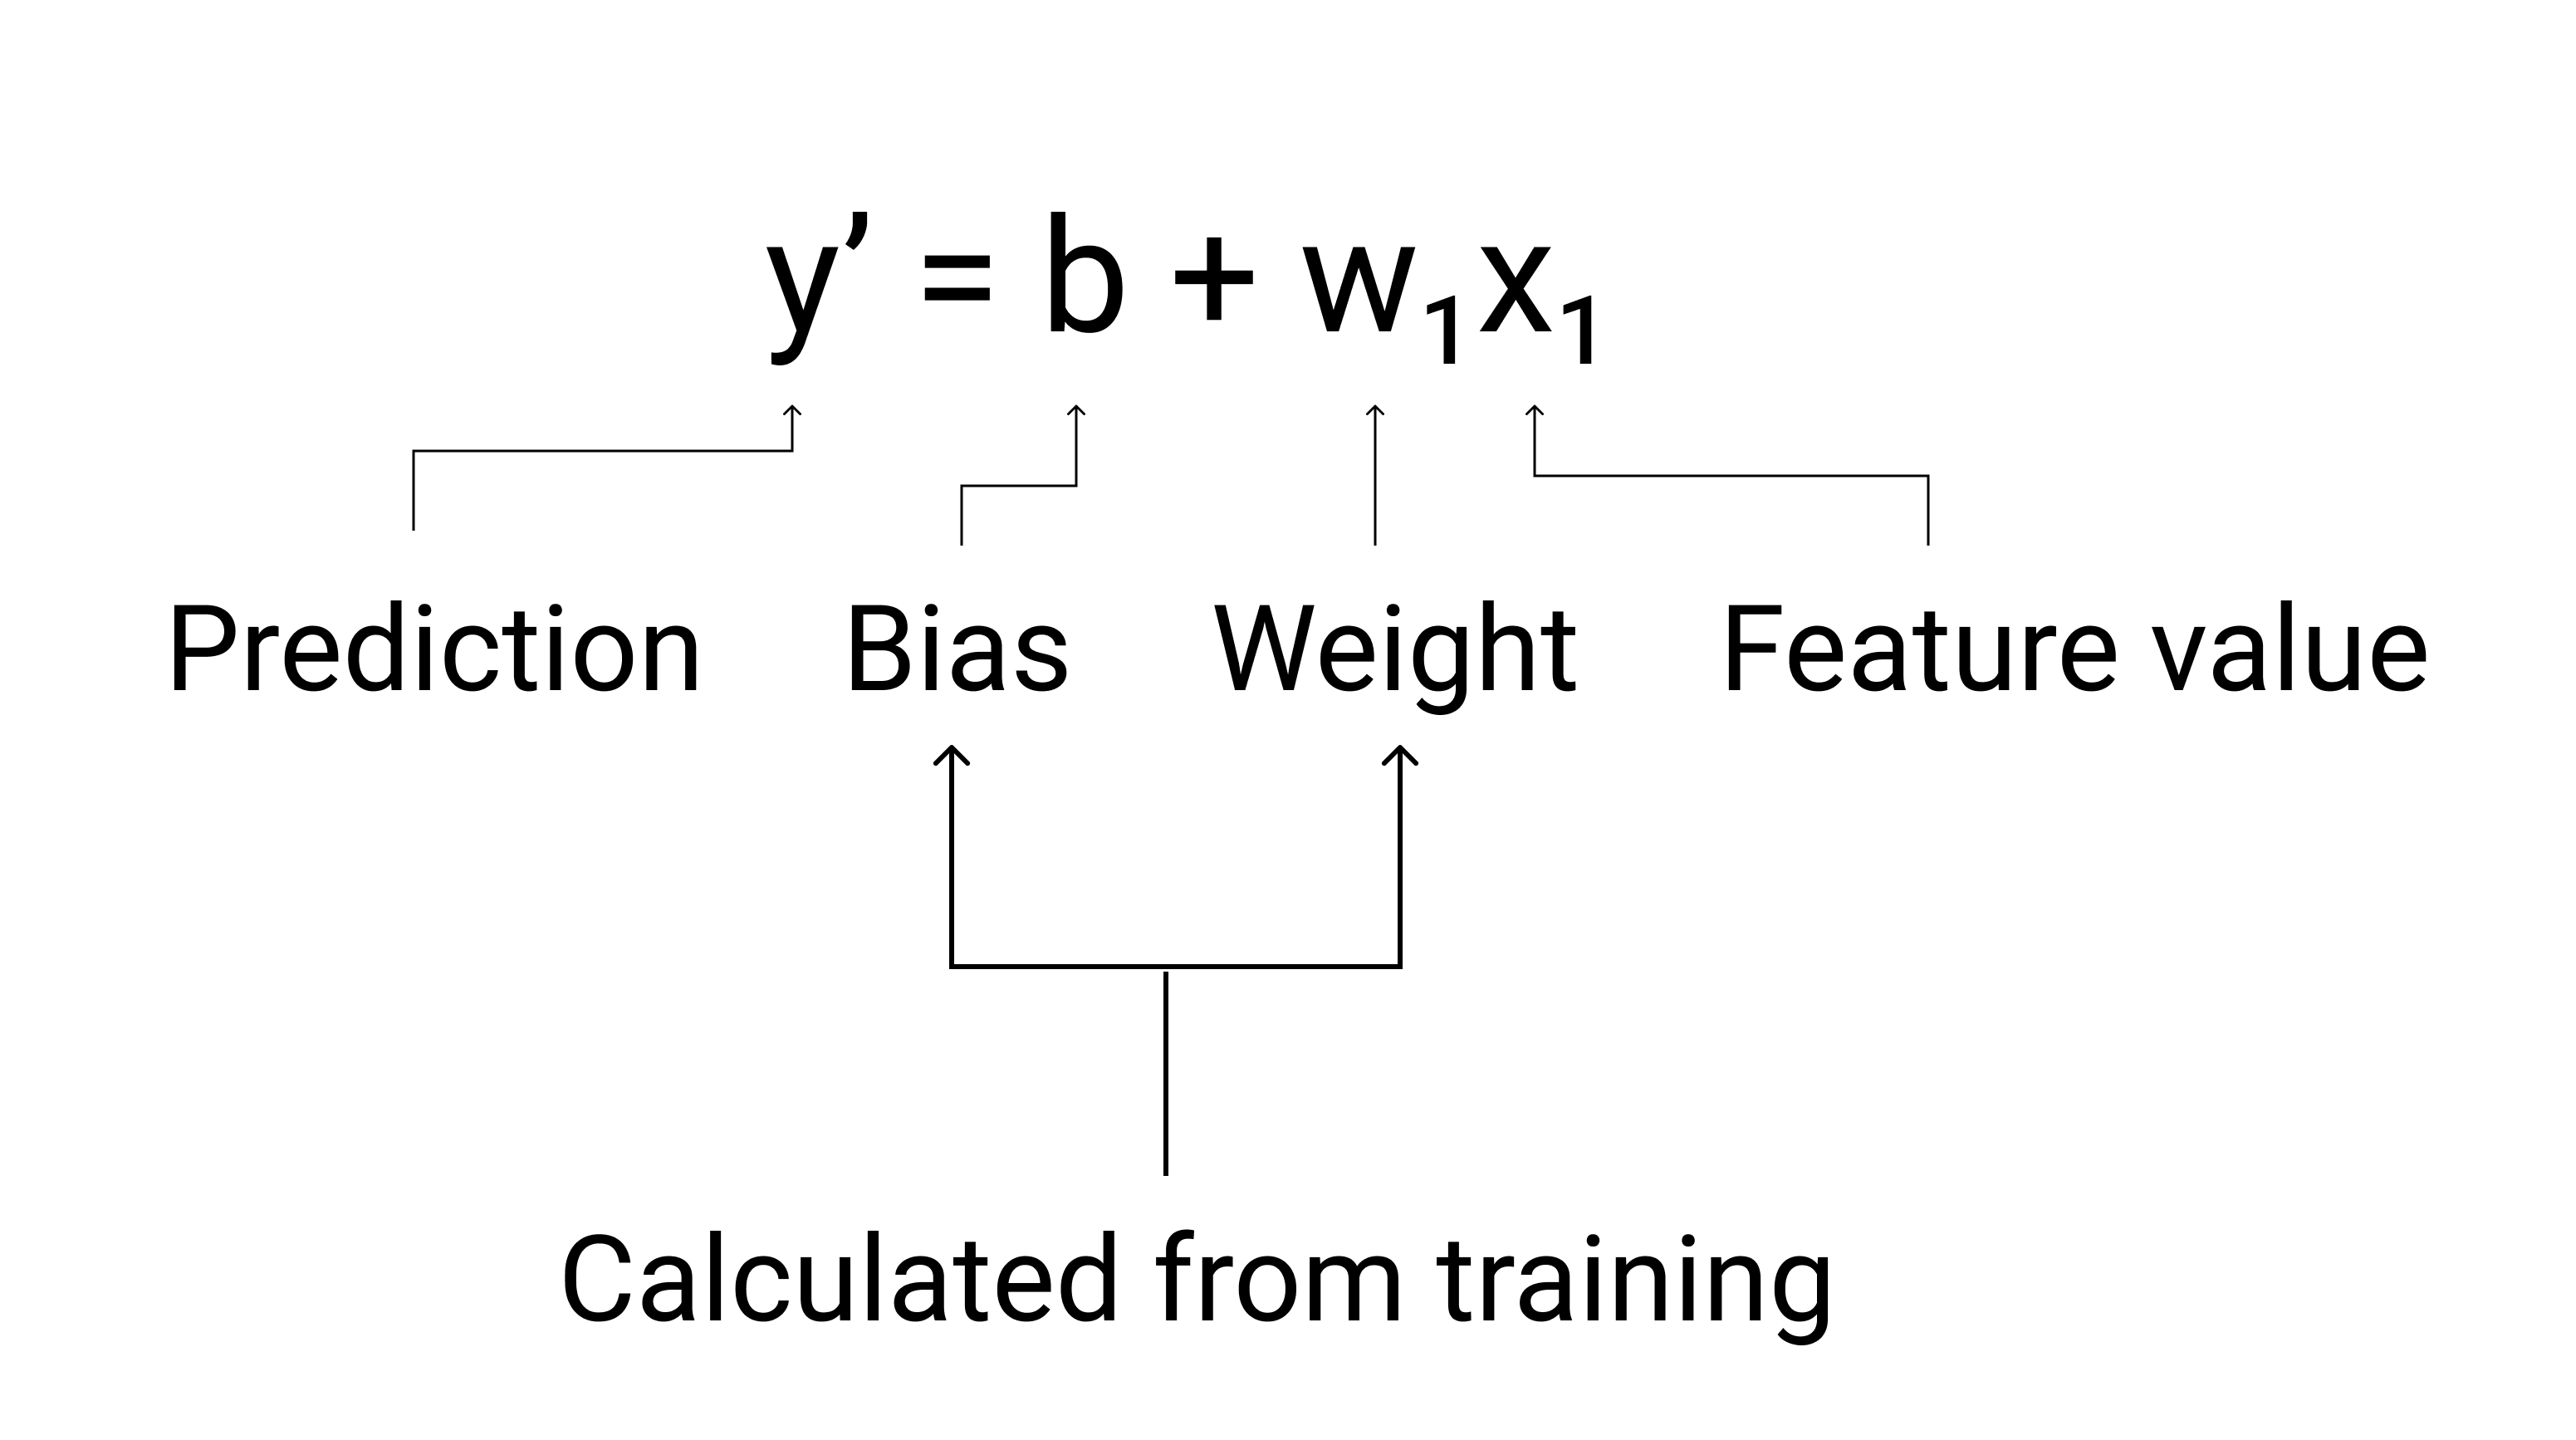

(source: Google for Developers)

**Loss** is a numerical metric that describes how wrong a model's **predictions** are. Loss measures the distance between the model's predictions and the actual labels.

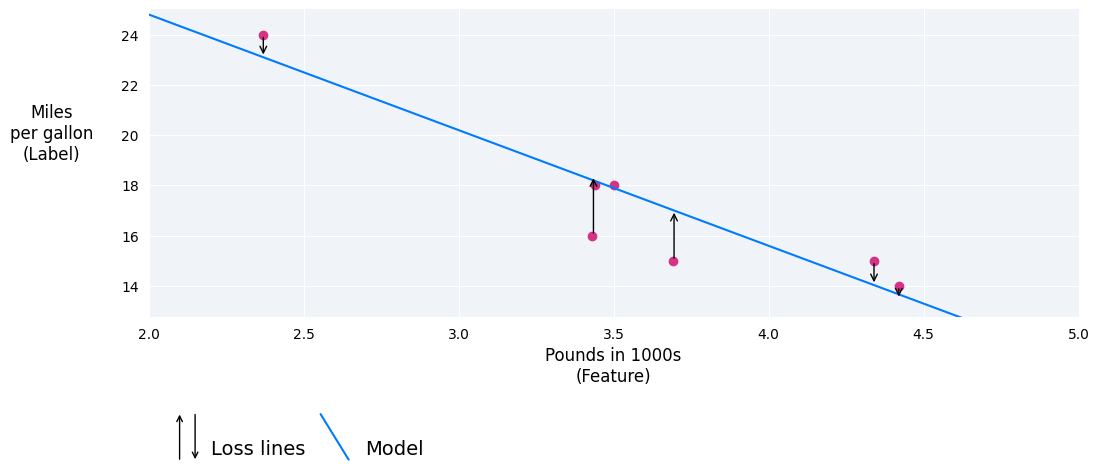
(source: Google for Developers)

**The goal of training a model is to minimize the loss, reducing it to its lowest possible value**.

###Exploring loss

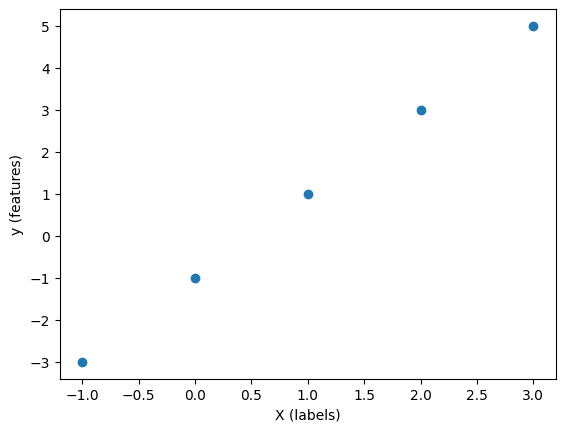

In [ ]:
# import library
import math
import matplotlib.pyplot as plt

# sample data
X = [-1, 0, 1, 2, 3] # features
y = [-3, -1, 1, 3, 5] # labels

# plot the data
plt.plot(X, y, 'o')
plt.xlabel('X (labels)')
plt.ylabel('y (features)')
plt.show()

In [ ]:
# exploring different weight (w) and bias (b) parameters for Y=wx+b
# you can change the values of w and b and see what happened with the loss value (solution w=2 and b=-1)
w = 3
b = -2

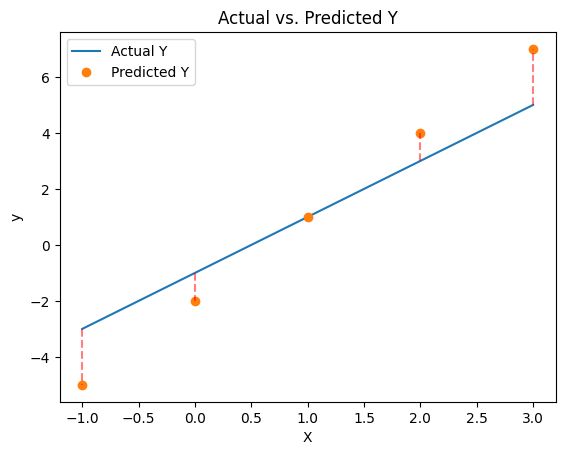

In [ ]:
# plot the predicted versus actual values
# set up an array for my predicted Y
myY = []

for thisX in X:
  thisY = (w*thisX)+b
  myY.append(thisY)

# plot the actual data as a line
plt.plot(X,y, '-', label='Actual Y')

# plot the predicted data as dots
plt.plot(X, myY, 'o', label='Predicted Y')

# Add drop lines from predicted Y to actual Y
for i in range(len(X)):
    plt.vlines(X[i], y[i], myY[i], color='red', linestyle='dashed', alpha=0.5)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Actual vs. Predicted Y')
plt.legend()
plt.show()

In [ ]:
# Calculate the loss (you can try to calculate the loss mannually too)
total_square_error = 0
for i in range(0, len(y)):
  square_error = (y[i] - myY[i]) ** 2
  total_square_error += square_error

print(f"My loss is: {str(math.sqrt(total_square_error))}")

My loss is: 3.1622776601683795


**Excisie**: Let's try using weight (w) and bias (b) parameters!

Let's explore the relationship between disease severity and yield loss, using dummy data of a fungicide trial.

In [ ]:
# load libraries
import numpy as np # numerical Python library
import pandas as pd # pandas dataframe
from pandas import read_csv # pandas read csv file
import matplotlib.pyplot as plt # plotting figures

# load the dataset
df_fungicide = pd.read_csv('./data/fungicide_trial_dummy_data.csv')

# check the information of the dataframe
df_fungicide.info()

# check a subset of data
df_fungicide.head()
# df_fungicide.tail() # you try this too

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rep                       60 non-null     int64  
 1   plot                      60 non-null     int64  
 2   fungicide_treatment       0 non-null      float64
 3   disease_severity_percent  60 non-null     int64  
 4   yield_pounds_per_acre     60 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 2.5 KB


,rep,plot,fungicide_treatment,disease_severity_percent,yield_pounds_per_acre
0,1,101,NaN,5,3272
1,1,102,NaN,15,3088
2,1,103,NaN,13,3389
3,1,104,NaN,21,2906
4,1,105,NaN,17,2917


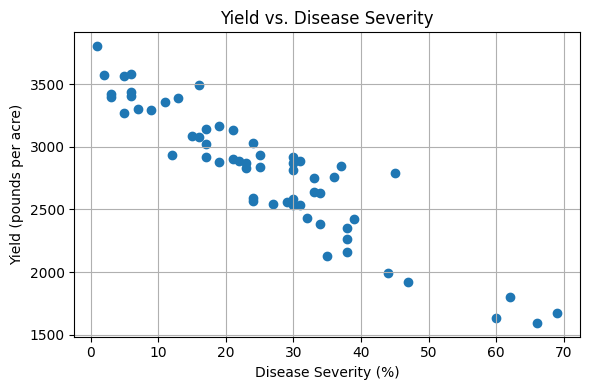

In [ ]:
# plot disease severity as x and yield as y
plt.figure(figsize=(6, 4))
plt.scatter(df_fungicide['disease_severity_percent'], df_fungicide['yield_pounds_per_acre'])
plt.xlabel('Disease Severity (%)')
plt.ylabel('Yield (pounds per acre)')
plt.title('Yield vs. Disease Severity')
plt.grid(True)
plt.tight_layout()
plt.show()

In practice, both data and models are much more complicated. How to find the optimal weight(s) and bias?

### Gradient descent

**Gradient descent** is a mathematical technique that iteratively finds the weights and bias that produce the model with the lowest loss.

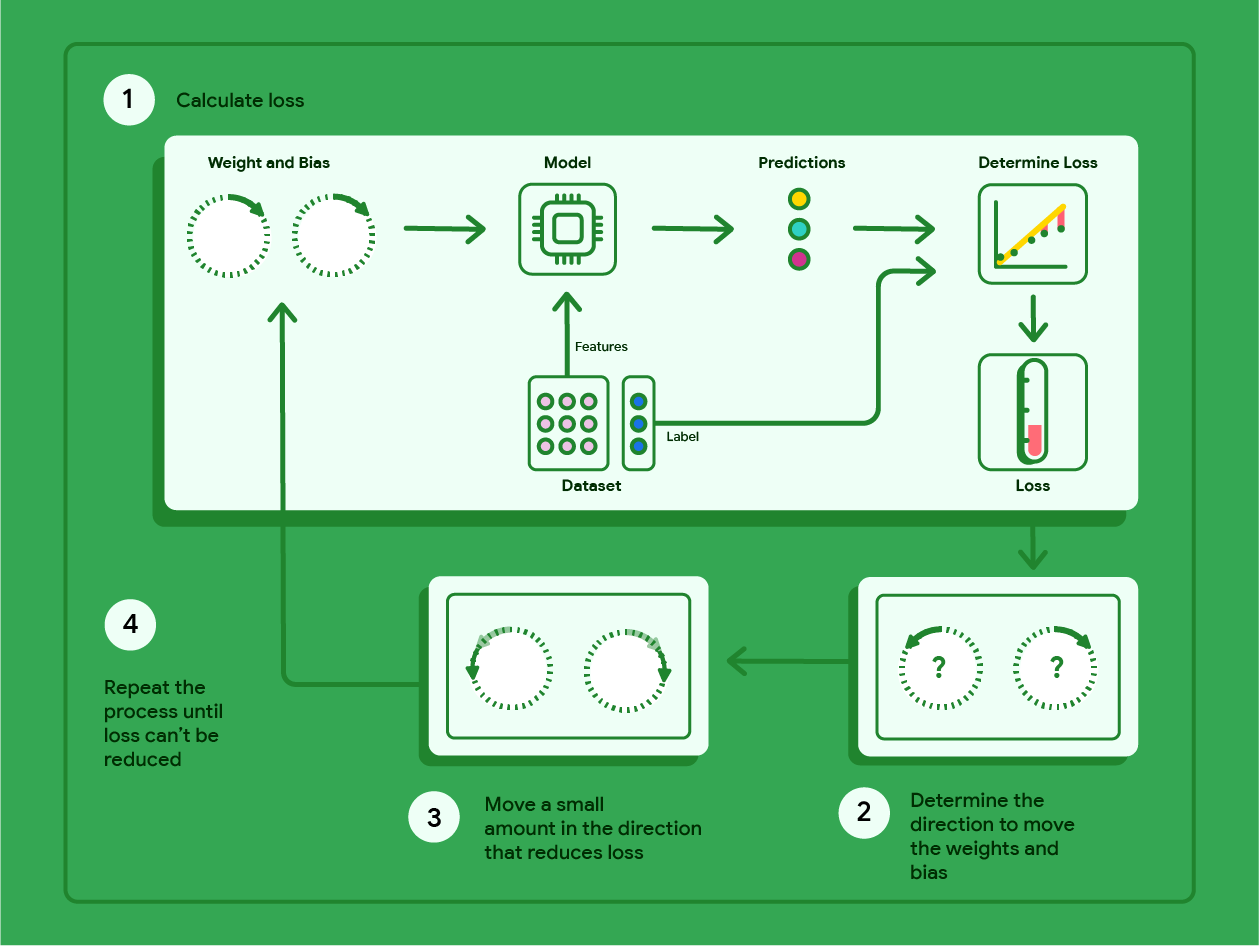

**Iteration** is a single update of a model's parameters—the model's weights and biases—during training.

**Learning rate** is a floating point number you set that influences how quickly the model converges. If the learning rate is too low, the model can take a long time to converge. However, if the learning rate is too high, the model never converges, but instead bounces around the weights and bias that minimize the loss.

(source: Google for Developers)

In [ ]:
# Set X and y values
X_fun = df_fungicide['disease_severity_percent'].values
y_fun = df_fungicide['yield_pounds_per_acre'].values

# Normalize the input feature (important for gradient descent)
X_norm = (X_fun - np.mean(X_fun)) / np.std(X_fun)

In [ ]:
# Initialize Parameters
w = 0.0  # weight (slope)
b = 0.0  # bias (intercept)

# Hyperparameters
lr = 0.2        # learning rate (ideal lr is problem-dependent, but it looks like 0.1 works well for this dataset)
n_iter = 100      # number of iterations

In [ ]:
# To track training
loss_history = []

# Run Gradient Descent
for i in range(n_iter):
    y_pred = w * X_norm + b
    error = y_fun - y_pred
    loss = np.mean(error ** 2)

    # Gradients
    dw = -2 * np.mean(X_norm * error)
    db = -2 * np.mean(error)

    # Update parameters
    w -= lr * dw
    b -= lr * db

    loss_history.append(loss)

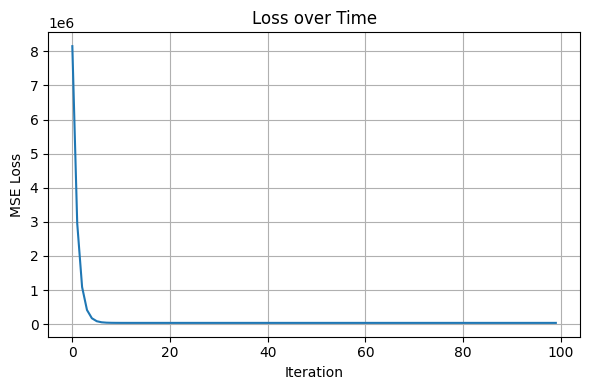

In [ ]:
# Plot Loss Curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

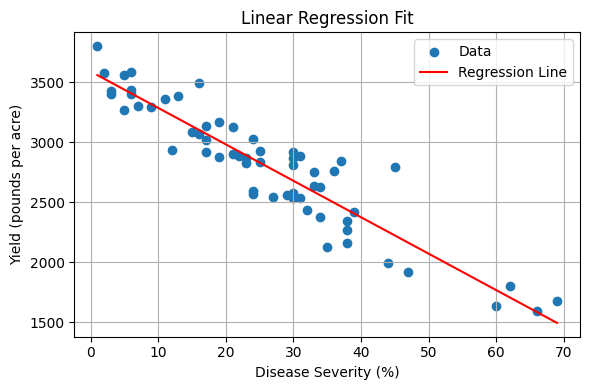

Final weight (slope): -475.5023
Final bias (intercept): 2808.7333
Final Mean Squared Error: 35634.0363


In [ ]:
#  Visualize Regression Fit
X_plot = np.linspace(min(X_norm), max(X_norm), 100)
y_plot = w * X_plot + b

# Convert normalized X back to original severity values
X_unorm_plot = X_plot * np.std(X_fun) + np.mean(X_fun)

# Calculate the final predicted values using the optimized weight and bias
final_y_pred = w * X_norm + b
# Calculate the Mean Squared Error
final_mse = np.mean((y_fun - final_y_pred) ** 2)

plt.figure(figsize=(6, 4))
plt.scatter(X_fun, y_fun, label='Data')
plt.plot(X_unorm_plot, y_plot, color='red', label='Regression Line')
plt.xlabel('Disease Severity (%)')
plt.ylabel('Yield (pounds per acre)')
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print Final Model Parameters
print(f"Final weight (slope): {w:.4f}")
print(f"Final bias (intercept): {b:.4f}")
print(f"Final Mean Squared Error: {final_mse:.4f}")

**Excisie**: Let's try using different learning rates (lr)!

## **Logistic regression**

Linear regression model makes continuous numerical predictions;

Logistic regression model predicts the proballity of a given outcome.

## **Classification**

Classification is the task of predicting which classes (categories) a sample belongs to.

A binary classification model (0 or 1) is converted from a logistic regression model (0 to 1).

### Dataset Exploration

#### Load libraries and data

In [ ]:
# load libraries
import numpy as np # numerical Python library
import pandas as pd # pandas dataframe
from pandas import read_csv # pandas read csv file
import matplotlib.pyplot as plt # plotting figures

In [ ]:
# load the dataset
df_spec = pd.read_csv('./data/peanut_stem_rot_spectral_data.csv') # load the data

# check the information of the dataframe
df_spec.info()

# check a subset of data
df_spec.head() # disease_severity: 0 = Healthy; 1 = Presymptomatic; 2 = Lesion_only; 3 = Mild; 4 = Severe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Columns: 159 entries, treatment to 899.225586
dtypes: float64(157), int64(1), object(1)
memory usage: 495.8+ KB


,treatment,disease_severity,242.36412,246.95195,251.535172,256.113861,260.687927,265.257385,269.822296,274.382599,...,865.050293,868.911255,872.766907,876.617249,880.462219,884.301941,888.13623,891.965271,895.788879,899.225586
0,mock-inoculated,0,4.379033,4.243781,4.292790,3.746052,3.604976,3.438778,3.442950,3.641581,...,84.648964,82.041755,77.425155,75.336659,70.920917,68.044431,70.480797,72.866164,69.854774,71.663773
1,mock-inoculated,0,3.914614,4.113802,4.318144,3.975428,3.782629,3.754157,3.636937,3.534895,...,65.342803,67.257730,65.370617,64.981325,65.311168,67.793237,67.859917,65.166605,65.482514,65.194357
2,mock-inoculated,0,5.306052,4.781971,4.581165,4.219214,4.196653,4.092795,4.032428,3.800115,...,67.122981,64.159309,63.343938,63.127599,66.559265,68.382680,67.940824,65.554937,66.720411,66.909241
3,mock-inoculated,0,4.290927,4.124496,3.848570,3.356648,3.572660,3.643015,3.423580,3.408087,...,71.905829,71.489346,71.082525,71.447937,70.242123,68.524612,69.717407,70.993827,69.043014,68.337850
4,mock-inoculated,0,4.456511,4.551076,4.495815,4.410871,4.241086,4.228564,4.082194,3.960146,...,63.263025,61.357398,62.194651,64.269729,66.334745,67.935672,65.566806,64.018784,65.861331,64.999612


In [ ]:
# check the number of classes in the dataset
trtlist = list(df_spec.treatment.unique()) # treatment: mock-inoculated and inoculated
print ('treatment:', trtlist)

# check the number of classes in the dataset
severity = list(df_spec.disease_severity.unique()) # disease_severity: 0 = Healthy; 1 = Presymptomatic; 2 = Lesion_only; 3 = Mild; 4 = Severe
print ('disease_severity:', severity)

treatment: ['mock-inoculated', 'inoculated']
disease_severity: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


#### Data cleaning and visualization

In [ ]:
## make the column names of wavelength without decimals

# Identify wavelength columns (assuming they are all columns except 'treatment' and 'disease_severity')
wavelength_cols = df_spec.columns[2:]
# Create a dictionary to map old column names to new integer column names
rename_dict = {col: int(float(col)) for col in wavelength_cols}
# Rename the columns
df_spec = df_spec.rename(columns=rename_dict)

# Display the updated column names to verify
print(df_spec.columns)

Index([       'treatment', 'disease_severity',                242,
                      246,                251,                256,
                      260,                265,                269,
                      274,
       ...
                      865,                868,                872,
                      876,                880,                884,
                      888,                891,                895,
                      899],
      dtype='object', length=159)


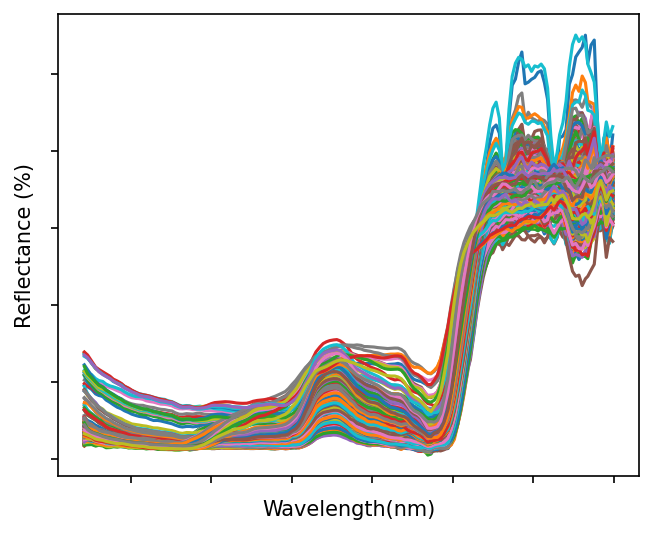

In [ ]:
# plot the original spectrum profiles and examine no outliners
fig,ax = plt.subplots(figsize=(5,4), dpi=150)
ax.plot(df_spec.iloc[:, 2:159].T)
ax.set_ylabel('Reflectance (%)')
ax.set_xlabel('Wavelength(nm)')

# Turn off tick labels
ax.set_yticklabels([])
ax.set_xticklabels([])

plt.show()

###Train the model

In [ ]:
# Set this parameter to True for binary classification, False for multi-class classification
use_binary = True

In [ ]:
# Define X and y based on classification type
X_spec = df_spec.iloc[:, 2:159]  # input spectral features

if use_binary:
    y_spec = df_spec.iloc[:, 0]  # binary classification using treatment
    target_names = ["Mock-inoculated", "Inoculated"]
else:
    y_spec = df_spec.iloc[:, 1]  # multi-class classification using disease severity
    target_names = ["Healthy", "Presymptomatic", "Lesion_only", "Mild", "Severe"]

# Print shape for confirmation
print("Shape of dataset:", X_spec.shape, y_spec.shape)
print("Target names:", target_names)

Shape of dataset: (399, 157) (399,)
Target names: ['Mock-inoculated', 'Inoculated']


#### Data splitting

* Training data = 70%
* Test data = 30%

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
SPLIT_RND_SEED = 123
X_train, X_test, y_train, y_test = train_test_split(X_spec, y_spec,
                                                    test_size=0.3,
                                                    random_state=SPLIT_RND_SEED)  # 70% training and 30% test

print("Using", len(X_train), "measurements for training,", len(y_test), "measurements for testing")

Using 279 measurements for training, 120 measurements for testing


In [ ]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((279, 157), (120, 157))

#### Model building

In [ ]:
# Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier # you can try other classifiers too from the scikit-learn library

# Create a Random Forest Classifier with 50 trees
rf = RandomForestClassifier(n_estimators = 50,
                                   oob_score=True,
                                   random_state=12345, # random number to be used, needed to reproduce the same result
                                   verbose=False)
rf # show the model

RandomForestClassifier(n_estimators=50, oob_score=True, random_state=12345,
                       verbose=False)

#### Model fitting

In [ ]:
# Train the model using the training sets
rf_model = rf.fit(X_train, y_train)

# printing rhe classifier object shows its parameters
print(rf_model)

RandomForestClassifier(n_estimators=50, oob_score=True, random_state=12345,
                       verbose=False)


### Accuracy assessment

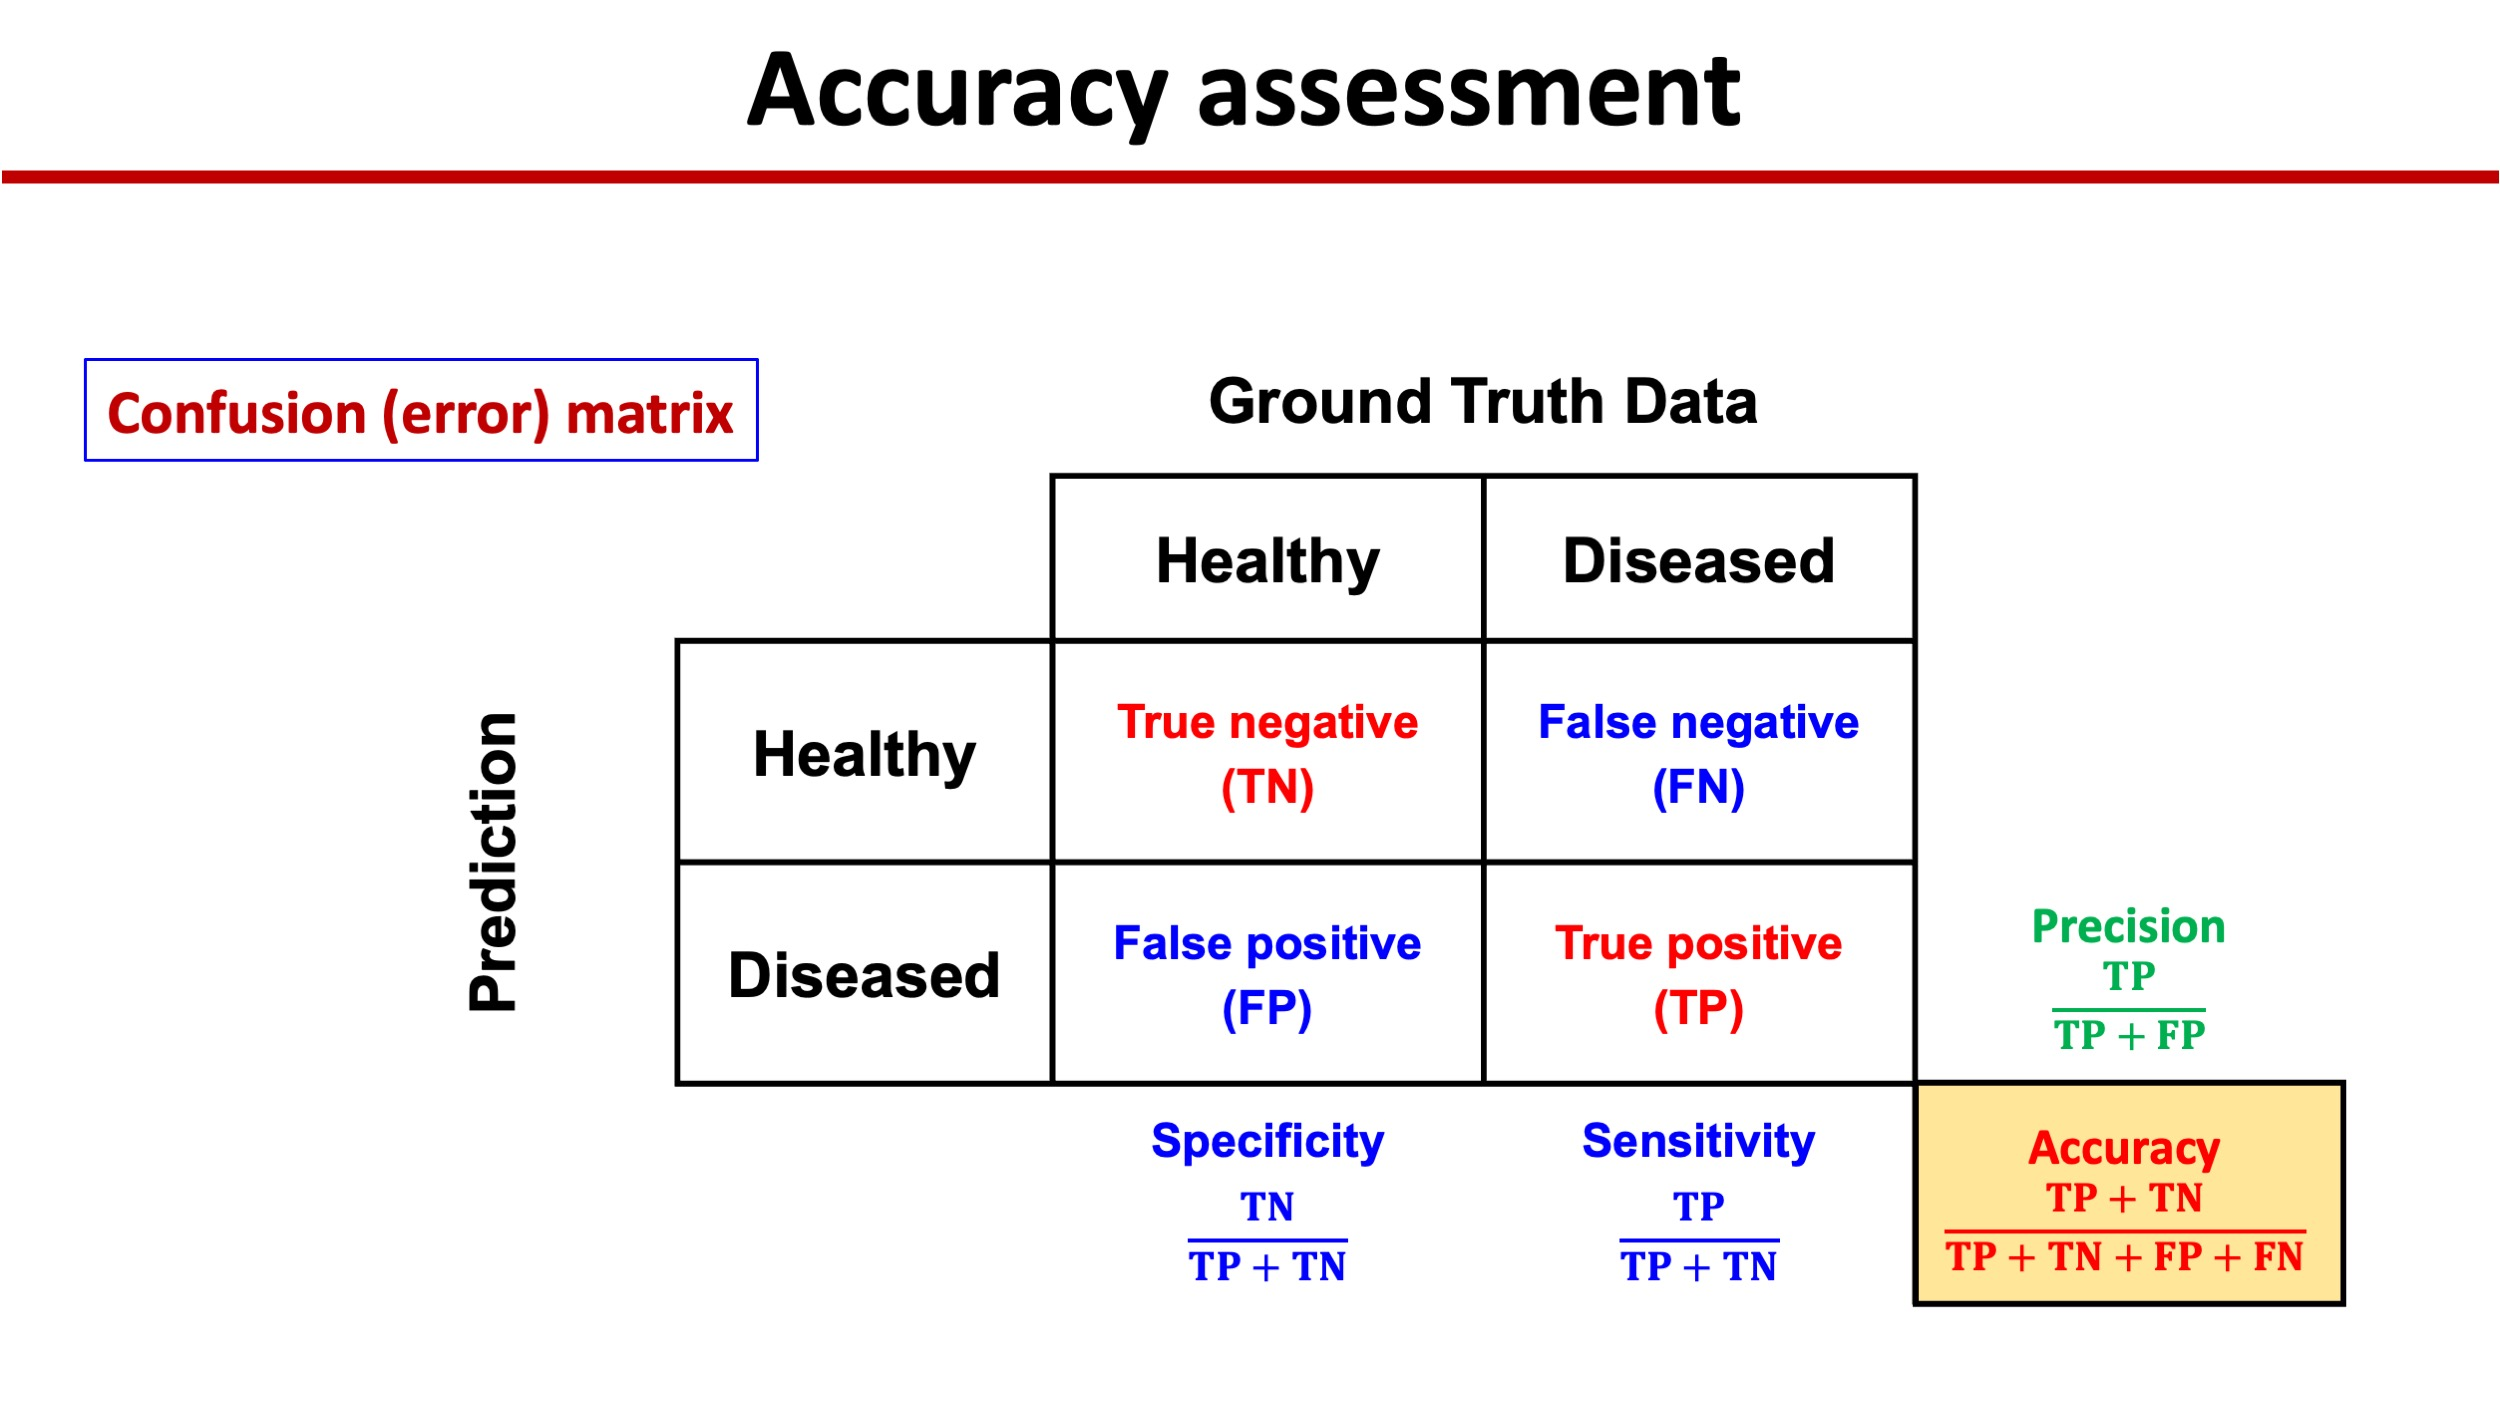

#### Trainning accuracy

In [ ]:
# Out of bag (OOB) score: a measure of the model's accuracy on the training data
print(f'Out-of-bag score estimate: {rf_model.oob_score_:.3}')

Out-of-bag score estimate: 0.849


#### Predication accuracy

In [ ]:
# Prediction on test data
y_pred = rf_model.predict(X_test)

In [ ]:
# Accuracy assessment
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print('Model accuracy is {:.3f}'.format(accuracy))

Model accuracy is 0.892


Text(89.72222222222221, 0.5, 'Predicted severity of PSR')

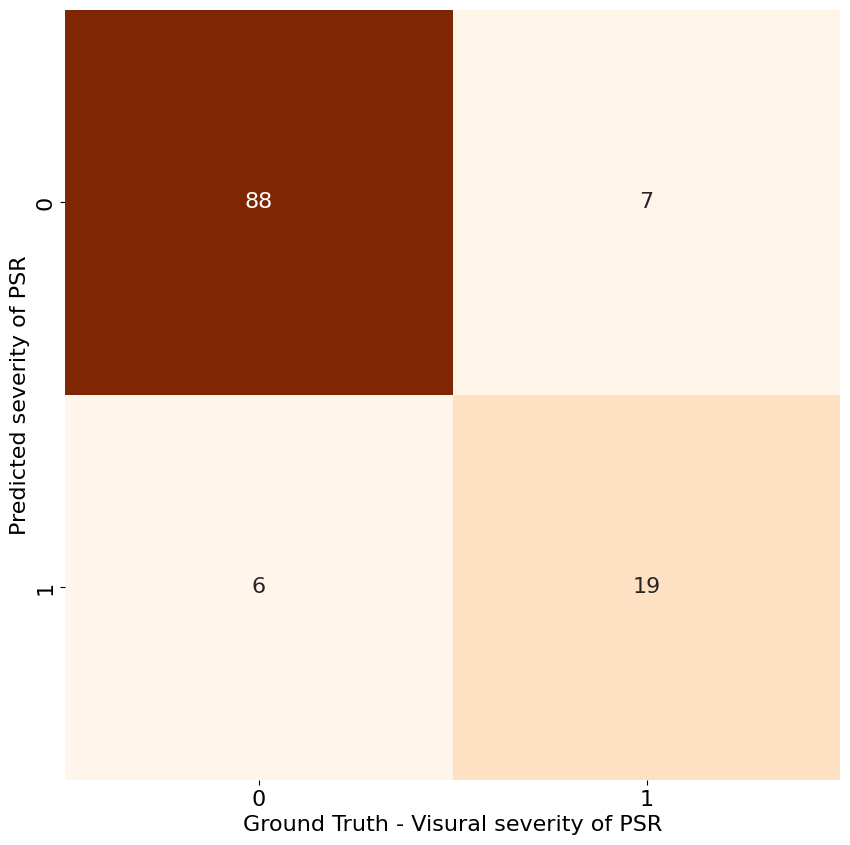

In [ ]:
# Confusion (error) Matrix of Prediction
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = pd.DataFrame(confusion_matrix(y_pred, y_test))

# use seaborn to plot matrix as heatmap
plt.rc('font', size=16)
p = sns.heatmap(cm,
                annot=True,
                cbar=False,
                cmap="Oranges")
plt.xlabel('Ground Truth - Visural severity of PSR')
plt.ylabel('Predicted severity of PSR')

#### Classification report

In [ ]:
from sklearn.metrics import classification_report

# Classification report
stats = classification_report(y_test, y_pred,
                              labels=None,
                              target_names=target_names,
                              sample_weight=None,
                              digits=2,
                              output_dict=False)

print("Classification report:\n")
print(stats)

Classification report:

                 precision    recall  f1-score   support

Mock-inoculated       0.93      0.94      0.93        94
     Inoculated       0.76      0.73      0.75        26

       accuracy                           0.89       120
      macro avg       0.84      0.83      0.84       120
   weighted avg       0.89      0.89      0.89       120



### Feature importance

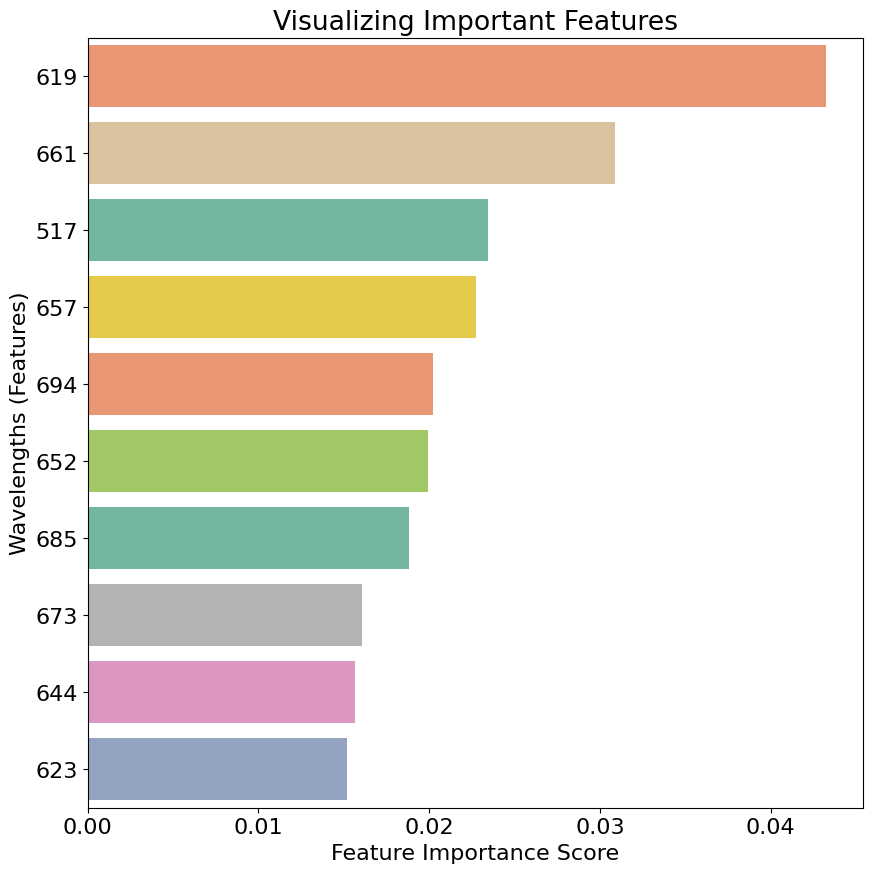

In [ ]:
# feature importance scores for the random forest model
feature_scores = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# only save the top n features into the list
top_n_features = feature_scores[0:10]

# display the predictions
plt.rcParams['figure.figsize'] = [10, 10]

palette = sns.color_palette("Set2", len(top_n_features)) # Ensure palette has enough colors

# Creating a seaborn bar plot
sns.barplot(x=top_n_features, y=top_n_features.index, palette=palette, hue=top_n_features.index, legend=False, orient='h', order=top_n_features.index) # Added order parameter
plt.title("Visualizing Important Features")
plt.xlabel('Feature Importance Score')
plt.ylabel('Wavelengths (Features)')

plt.show()

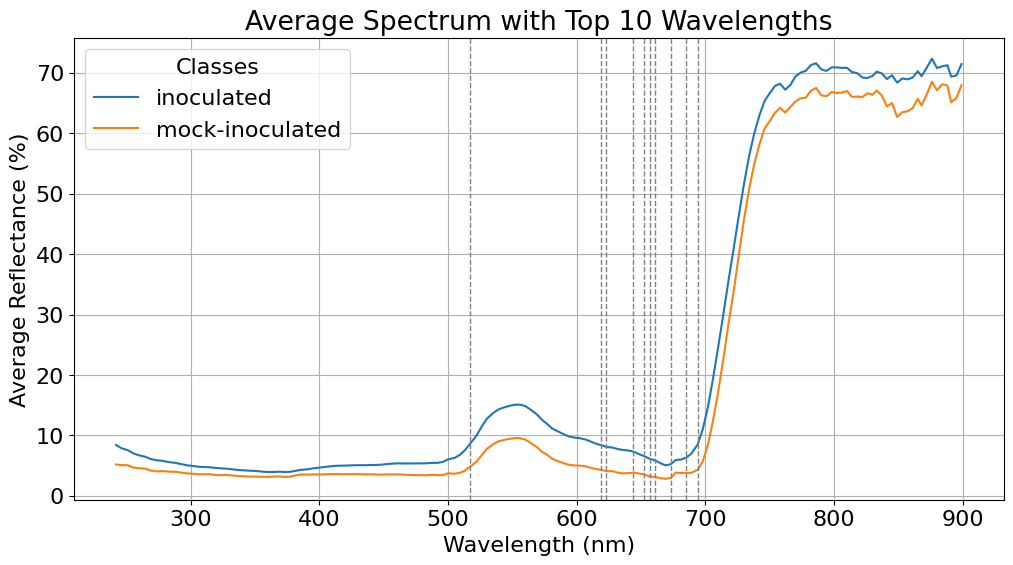

In [ ]:
# Viusalize wavelenghts with top feature scores

# Calculate average spectrum based on classification type
if use_binary:
    average_spectrum = df_spec.groupby('treatment')[df_spec.columns[2:]].mean().T
else:
    average_spectrum = df_spec.groupby('disease_severity')[df_spec.columns[2:]].mean().T

# Plot average spectrum for each group
plt.figure(figsize=(12, 6))
for col in average_spectrum.columns:
    # Use the target_names list for labeling based on use_binary flag
    if use_binary:
        # Get the treatment name directly from the column index
        label_name = col
    else:
        # Use severity level to index multi-class target names
        label_name = target_names[col]

    plt.plot(average_spectrum.index, average_spectrum[col], label=f'{label_name}')

# Add vertical lines for top 10 wavelengths
top_wavelengths = top_n_features.index.tolist()
for wavelength in top_wavelengths:
    plt.axvline(x=wavelength, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average Reflectance (%)')
plt.title('Average Spectrum with Top 10 Wavelengths')
plt.legend(title='Classes')
plt.grid(True)
plt.show()

**Excisie**: Let's try multi-class classification!

**Credits/References:**
* Raza, M.M and Wei, X. Introduction of Python and Machine Learning in Phytopathology. 2022. GitHub repository, https://github.com/MohsinRamay/Introduction-of-Python-and-Machine-Learning-in-Phytopathology-

* Wei, X., Johnson, M. A., Langston Jr, D. B., Mehl, H. L., and Li, S. 2021. Identifying optimal wavelengths as disease signatures using hyperspectral sensor and machine learning. Remote Sensing, 13(14), 2833. https://doi.org/10.3390/rs13142833